In [1]:
from pyspoc import Calculator, Config
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy.interpolate import griddata
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import seaborn as sns

Starting JVM with java class /Users/joshparchure/Documents/pyspocClone24Jun/py-spoc/pyspoc/lib/jidt/infodynamics.jar.
Jpype JVM not available: [Errno 2] JVM DLL not found: /Library/Internet Plug-Ins/JavaAppletPlugin.plugin/Contents/Home


In [2]:
project_root = Path('./').resolve().parents[3]
print(project_root)
directed_ratio_path = os.path.join(project_root,'mastersResearch_Jun_Sept2025','causalDiscovery_J','ReducedStatistics','directed_ratio.py')
print(directed_ratio_path)

/Users/joshparchure/pyspocClone5Aug/py-spoc/working_analyses
/Users/joshparchure/pyspocClone5Aug/py-spoc/working_analyses/mastersResearch_Jun_Sept2025/causalDiscovery_J/ReducedStatistics/directed_ratio.py


In [3]:
directed_ratio_config_yaml = f"""
ReducedStatistics:
  {directed_ratio_path}:
    DirectedRatio:
        schemes:
            scheme_1:
                alpha: 0.05
"""
directed_ratio_config_name = "directed_ratio"
cfg = Config.from_yaml(directed_ratio_config_name, directed_ratio_config_yaml)

Registering YAML string.
Building internal configuration.
/Users/joshparchure/pyspocClone5Aug/py-spoc/working_analyses/mastersResearch_Jun_Sept2025/causalDiscovery_J/ReducedStatistics/directed_ratio.py
    ✔ ReducedStatistic DirectedRatio scheme 'scheme_1' added successfully.


In [4]:
base_dir = os.path.join(project_root, 'mastersResearch_Jun_Sept2025', 'causalDiscovery_J')

In [5]:
motivation_dag_1 = os.path.join(base_dir,'motivationAnalysis', 'motivation_dag_1.csv')
dag2dataset1 = os.path.join(base_dir, 'dataGen', 'loop100data', 'dag2dataset1.csv')

dag2dataset1_df = pd.read_csv(dag2dataset1)
calc = Calculator(dag2dataset1_df)
calc.compute(cfg)
results = calc.results
print(results)

Normalising the dataset...



Processing [None: /Users/joshparchure/pyspocClone5Aug/py-spoc/working_analyses/mastersResearch_Jun_Sept2025/causalDiscovery_J/ReducedStatistics/directed_ratio.py.DirectedRatio.scheme_1]:   0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Processing [None: /Users/joshparchure/pyspocClone5Aug/py-spoc/working_analyses/mastersResearch_Jun_Sept2025/causalDiscovery_J/ReducedStatistics/directed_ratio.py.DirectedRatio.scheme_1]: 100%|██████████| 1/1 [00:04<00:00,  4.55s/it]


Calculation complete. Time taken: 4.5535s
Statistic /Users/joshparchure/pyspocClone5Aug/py-spoc/working_analyses/mastersResearch_Jun_Sept2025/causalDiscovery_J/ReducedStatistics/directed_ratio.py.DirectedRatio.scheme_1
Reducer                                                                                                                                                                     self
0                                                   0.091837                                                                                                                    


In [24]:
print(results.iloc[0,0])

0.09183673468450645


---
### Subsampling

In [60]:
N_values = np.arange(100, 1001, 100)
p_values = np.arange(10, 101, 10)
reps = 5

results_list = []

for current_N in N_values:
    for current_p in p_values:
        statistic_sum = 0
        for _ in range(reps):
            subsampled_df = dag2dataset1_df.sample(n=current_N, axis=0).sample(n=current_p, axis=1)
            calc = Calculator(subsampled_df)
            calc.compute(cfg)
            results = calc.results
            statistic_sum+=results.iloc[0,0]
        avg_statistic = statistic_sum / reps
        results_list.append({
            'N': current_N,
            'p': current_p,
            'avg_statistic': avg_statistic
        })

results_df = pd.DataFrame(results_list)
display(results_df)

Normalising the dataset...



Processing [None: /Users/joshparchure/pyspocClone5Aug/py-spoc/working_analyses/mastersResearch_Jun_Sept2025/causalDiscovery_J/ReducedStatistics/directed_ratio.py.DirectedRatio.scheme_1]:   0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Processing [None: /Users/joshparchure/pyspocClone5Aug/py-spoc/working_analyses/mastersResearch_Jun_Sept2025/causalDiscovery_J/ReducedStatistics/directed_ratio.py.DirectedRatio.scheme_1]: 100%|██████████| 1/1 [00:00<00:00, 33.87it/s]



Calculation complete. Time taken: 0.0313s
Normalising the dataset...



...

Processing [None: /Users/joshparchure/pyspocClone5Aug/py-spoc/working_analyses/mastersResearch_Jun_Sept2025/causalDiscovery_J/ReducedStatistics/directed_ratio.py.DirectedRatio.scheme_1]:   0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Processing [None: /Users/joshparchure/pyspocClone5Aug/py-spoc/working_analyses/mastersResearch_Jun_Sept2025/causalDiscovery_J/ReducedStatistics/directed_ratio.py.DirectedRatio.scheme_1]: 100%|██████████| 1/1 [00:04<00:00,  4.32s/it]


Calculation complete. Time taken: 4.3205s


,N,p,avg_statistic
0,100,10,0.293333
1,100,20,0.281538
2,100,30,0.132174
3,100,40,0.142131
4,100,50,0.184128
...,...,...,...
95,1000,60,0.175160
96,1000,70,0.225242
97,1000,80,0.145642
98,1000,90,0.147394


In [61]:
display(results_df)

,N,p,avg_statistic
0,100,10,0.293333
1,100,20,0.281538
2,100,30,0.132174
3,100,40,0.142131
4,100,50,0.184128
...,...,...,...
95,1000,60,0.175160
96,1000,70,0.225242
97,1000,80,0.145642
98,1000,90,0.147394


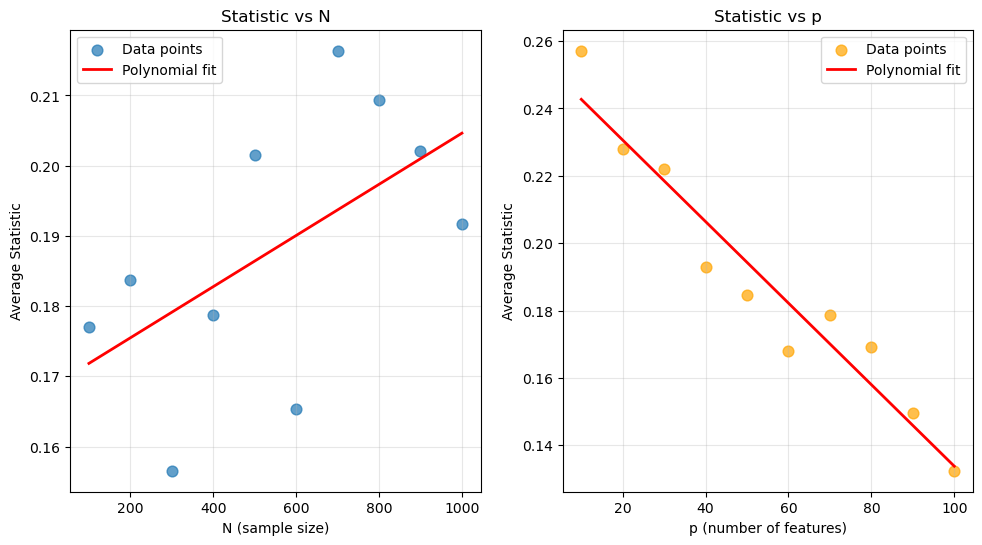

In [70]:
plt.style.use('default')

# Create figure with subplots
fig = plt.figure(figsize=(18, 6))

# 1. Plot statistic vs N with polynomial fit
ax1 = plt.subplot(1, 3, 1)

# Group by N and get mean statistic for each N (averaging across all p values)
n_grouped = results_df.groupby('N')['avg_statistic'].mean().reset_index()

# Polynomial fit for N
poly_reg_n = Pipeline([
    ('poly', PolynomialFeatures(degree=1)),
    ('linear', LinearRegression())
])
poly_reg_n.fit(n_grouped['N'].values.reshape(-1, 1), n_grouped['avg_statistic'])

# Generate smooth curve for plotting
n_smooth = np.linspace(n_grouped['N'].min(), n_grouped['N'].max(), 100)
n_pred = poly_reg_n.predict(n_smooth.reshape(-1, 1))

# Plot
plt.scatter(n_grouped['N'], n_grouped['avg_statistic'], alpha=0.7, s=60, label='Data points')
plt.plot(n_smooth, n_pred, 'r-', linewidth=2, label='Polynomial fit')
plt.xlabel('N (sample size)')
plt.ylabel('Average Statistic')
plt.title('Statistic vs N')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Plot statistic vs p with polynomial fit
ax2 = plt.subplot(1, 3, 2)

# Group by p and get mean statistic for each p (averaging across all N values)
p_grouped = results_df.groupby('p')['avg_statistic'].mean().reset_index()

# Polynomial fit for p
poly_reg_p = Pipeline([
    ('poly', PolynomialFeatures(degree=1)),
    ('linear', LinearRegression())
])
poly_reg_p.fit(p_grouped['p'].values.reshape(-1, 1), p_grouped['avg_statistic'])

# Generate smooth curve for plotting
p_smooth = np.linspace(p_grouped['p'].min(), p_grouped['p'].max(), 100)
p_pred = poly_reg_p.predict(p_smooth.reshape(-1, 1))

# Plot
plt.scatter(p_grouped['p'], p_grouped['avg_statistic'], alpha=0.7, s=60, label='Data points', color='orange')
plt.plot(p_smooth, p_pred, 'r-', linewidth=2, label='Polynomial fit')
plt.xlabel('p (number of features)')
plt.ylabel('Average Statistic')
plt.title('Statistic vs p')
plt.legend()
plt.grid(True, alpha=0.3)

In [65]:
# Print polynomial coefficients for interpretation
print("Polynomial fit coefficients:")
print(f"N relationship: {poly_reg_n.named_steps['linear'].coef_}")
print(f"p relationship: {poly_reg_p.named_steps['linear'].coef_}")
print(f"N intercept: {poly_reg_n.named_steps['linear'].intercept_}")
print(f"p intercept: {poly_reg_p.named_steps['linear'].intercept_}")

Polynomial fit coefficients:
N relationship: [ 0.00000000e+00 -9.62119955e-05  3.71056036e-08  4.70817594e-10
 -4.09411797e-13]
p relationship: [ 0.00000000e+00 -1.25486981e-03 -5.46646015e-05  1.23731267e-06
 -7.06994996e-09]
N intercept: 0.18816333329498938
p intercept: 0.27253093973069104


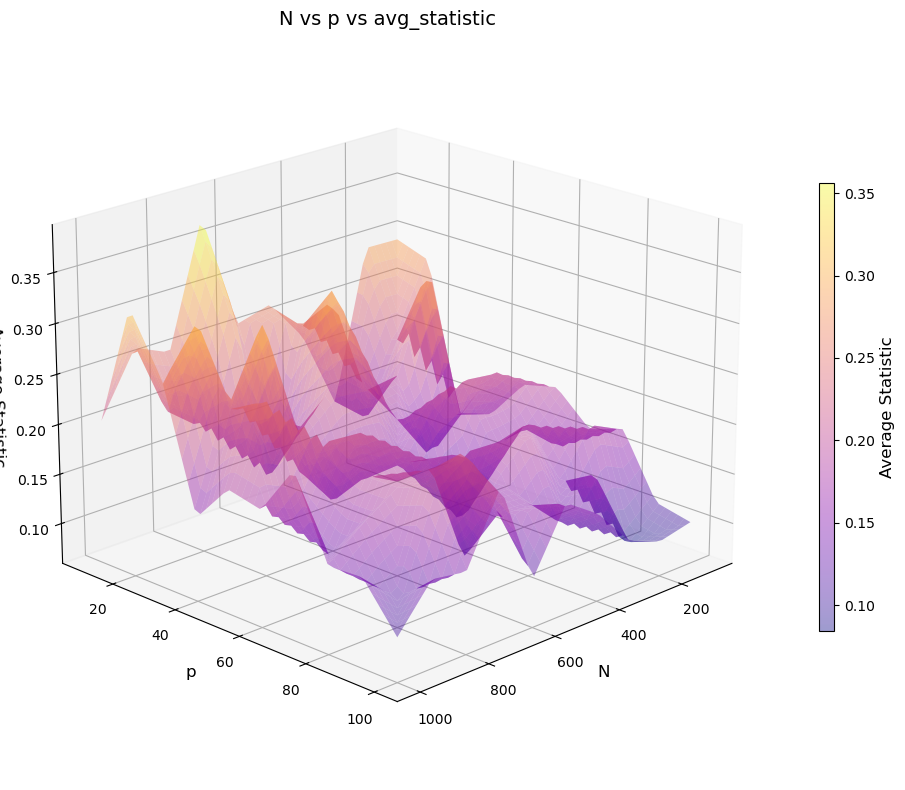

In [66]:
# 3. 3D surface plot
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

plt.style.use('default')
sns.set_palette('deep')

# Extract data for 3D plot
N = results_df['N'].values
p = results_df['p'].values
statistic = results_df['avg_statistic'].values

# Create a grid for surface fitting
N_unique = np.unique(N)
p_unique = np.unique(p)
N_grid, p_grid = np.meshgrid(N_unique, p_unique)

# Interpolate the statistic values onto the grid
statistic_grid = griddata((N, p), statistic, (N_grid, p_grid), method='cubic')

# Optional: Create a more detailed 3D plot with better surface fitting
fig2 = plt.figure(figsize=(12, 8))
ax4 = fig2.add_subplot(111, projection='3d')

# Create a finer grid for smoother surface
N_fine = np.linspace(N.min(), N.max(), 50)
p_fine = np.linspace(p.min(), p.max(), 50)
N_fine_grid, p_fine_grid = np.meshgrid(N_fine, p_fine)

# Interpolate with linear method for more stable results
statistic_fine_grid = griddata((N, p), statistic, (N_fine_grid, p_fine_grid), method='linear')

# Plot the fine surface
surface2 = ax4.plot_surface(N_fine_grid, p_fine_grid, statistic_fine_grid, 
                           alpha=0.4, cmap='plasma', linewidth=0, antialiased=True)

# Plot the original data points
scatter = ax4.scatter(N, p, statistic, color='white', s=60, alpha=0, 
                     edgecolors='black', linewidth=1, label='Data points')

ax4.set_xlabel('N', fontsize=12)
ax4.set_ylabel('p', fontsize=12)
ax4.set_zlabel('Average Statistic', fontsize=12)
ax4.set_title('N vs p vs avg_statistic', fontsize=14)

# Improve viewing angle
ax4.view_init(elev=20, azim=45)

# Add colorbar
cbar = plt.colorbar(surface2, ax=ax4, shrink=0.6, aspect=30)
cbar.set_label('Average Statistic', fontsize=12)

plt.tight_layout()
plt.show()

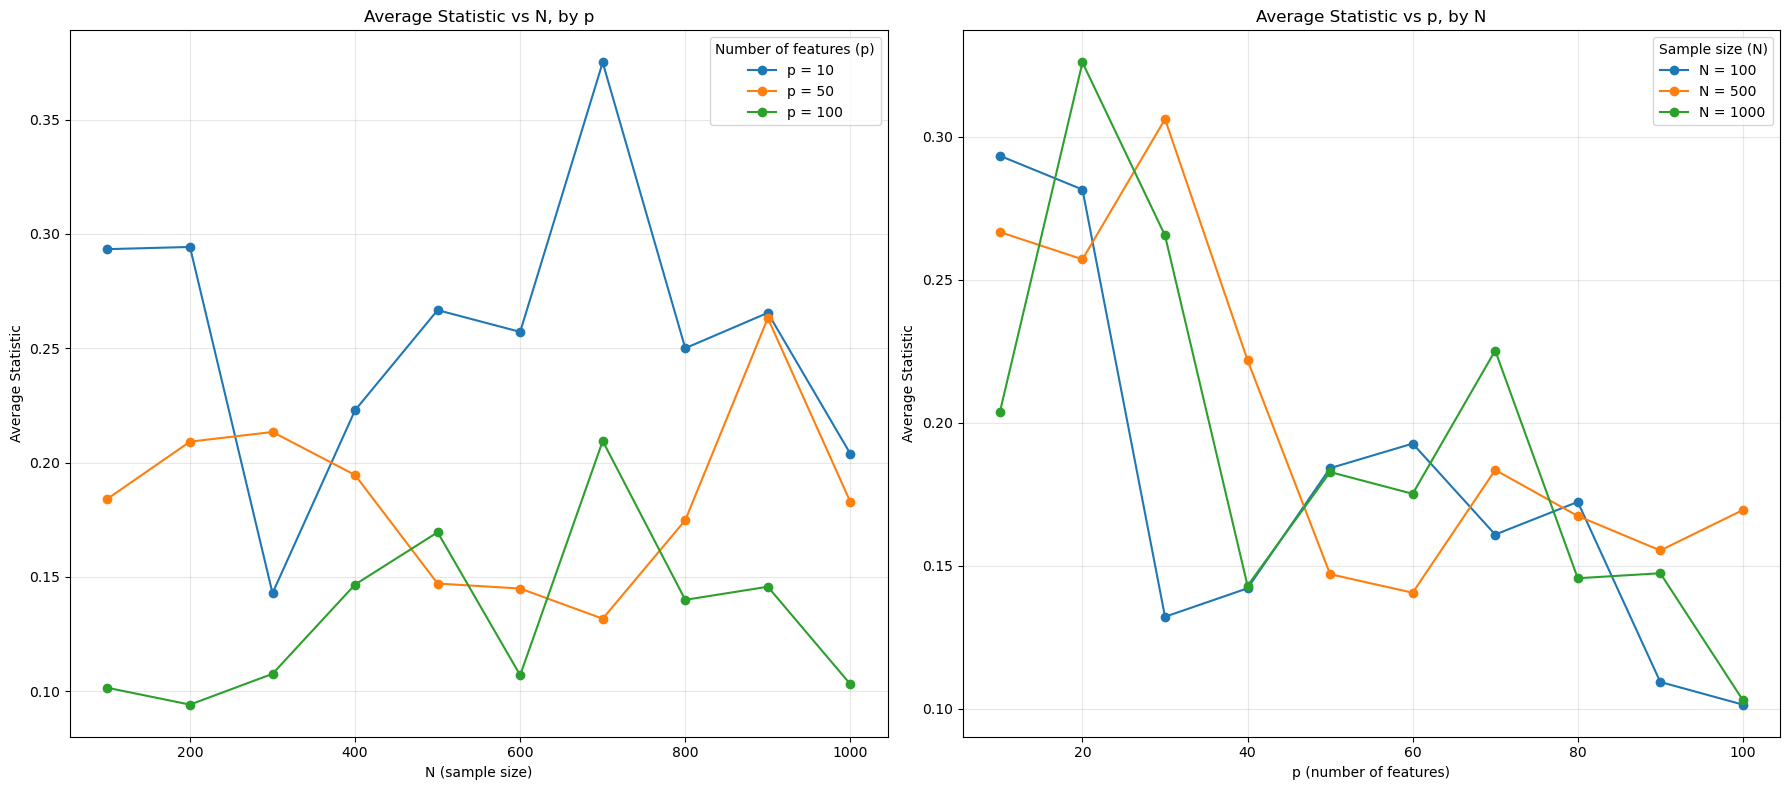

In [73]:
plt.style.use('default')

selected_p_values = [10, 50, 100]
selected_N_values = [100, 500, 1000]

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# 1. Plot statistic vs N, with separate lines for each p
# for p_val in sorted(results_df['p'].unique()):
for p_val in selected_p_values:
    df_p = results_df[results_df['p'] == p_val]
    ax1.plot(df_p['N'], df_p['avg_statistic'], marker='o', label=f'p = {p_val}')

ax1.set_xlabel('N (sample size)')
ax1.set_ylabel('Average Statistic')
ax1.set_title('Average Statistic vs N, by p')
ax1.legend(title='Number of features (p)')
ax1.grid(True, alpha=0.3)

# 2. Plot statistic vs p, with separate lines for each N
# for n_val in sorted(results_df['N'].unique()):
for n_val in selected_N_values:
    df_n = results_df[results_df['N'] == n_val]
    ax2.plot(df_n['p'], df_n['avg_statistic'], marker='o', label=f'N = {n_val}')

ax2.set_xlabel('p (number of features)')
ax2.set_ylabel('Average Statistic')
ax2.set_title('Average Statistic vs p, by N')
ax2.legend(title='Sample size (N)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [75]:
N_values = np.arange(100, 1001, 50)
reps = 10

results_list_varyN = []

for current_N in N_values:
    statistic_sum = 0
    for _ in range(reps):
        subsampled_df = dag2dataset1_df.sample(n=current_N, axis=0).sample(n=100, axis=1)
        calc = Calculator(subsampled_df)
        calc.compute(cfg)
        results = calc.results
        statistic_sum+=results.iloc[0,0]
    avg_statistic = statistic_sum / reps
    results_list_varyN.append({
        'N': current_N,
        'avg_statistic': avg_statistic
    })

results_df_varyN = pd.DataFrame(results_list_varyN)
display(results_df_varyN)

Normalising the dataset...



Processing [None: /Users/joshparchure/pyspocClone5Aug/py-spoc/working_analyses/mastersResearch_Jun_Sept2025/causalDiscovery_J/ReducedStatistics/directed_ratio.py.DirectedRatio.scheme_1]:   0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Processing [None: /Users/joshparchure/pyspocClone5Aug/py-spoc/working_analyses/mastersResearch_Jun_Sept2025/causalDiscovery_J/ReducedStatistics/directed_ratio.py.DirectedRatio.scheme_1]: 100%|██████████| 1/1 [00:04<00:00,  4.09s/it]



Calculation complete. Time taken: 4.0944s
Normalising the dataset...



...

Processing [None: /Users/joshparchure/pyspocClone5Aug/py-spoc/working_analyses/mastersResearch_Jun_Sept2025/causalDiscovery_J/ReducedStatistics/directed_ratio.py.DirectedRatio.scheme_1]:   0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Processing [None: /Users/joshparchure/pyspocClone5Aug/py-spoc/working_analyses/mastersResearch_Jun_Sept2025/causalDiscovery_J/ReducedStatistics/directed_ratio.py.DirectedRatio.scheme_1]: 100%|██████████| 1/1 [00:04<00:00,  4.34s/it]


Calculation complete. Time taken: 4.3393s


,N,avg_statistic
0,100,0.078576
1,150,0.081870
2,200,0.095496
3,250,0.113982
4,300,0.150171
5,350,0.100749
6,400,0.120948
7,450,0.134576
8,500,0.139071
9,550,0.128963


In [76]:
display(results_df_varyN)

,N,avg_statistic
0,100,0.078576
1,150,0.081870
2,200,0.095496
3,250,0.113982
4,300,0.150171
5,350,0.100749
6,400,0.120948
7,450,0.134576
8,500,0.139071
9,550,0.128963


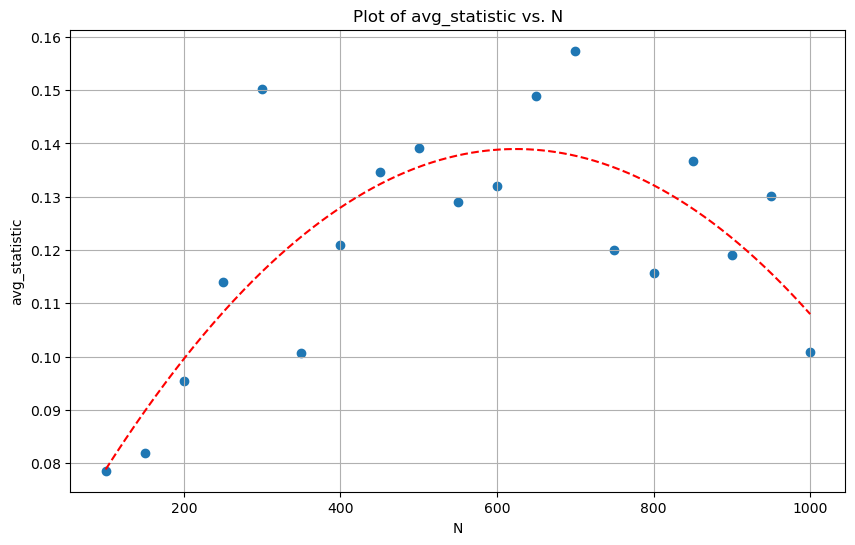

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(results_df_varyN['N'], results_df_varyN['avg_statistic'])

plt.xlabel('N')
plt.ylabel('avg_statistic')
plt.title('Plot of avg_statistic vs. N')
plt.grid(True)

degree = 2
coeffs = np.polyfit(results_df_varyN['N'], results_df_varyN['avg_statistic'], degree)
poly_func = np.poly1d(coeffs)
x_fit = np.linspace(results_df_varyN['N'].min(), results_df_varyN['N'].max(), 500)
plt.plot(x_fit, poly_func(x_fit), color='red', linestyle='--', label=f'Polynomial Fit (degree={degree})')

plt.show()